# Fraud Detection MLOps Pipeline
## Phase 3 - Deployment
---
**Goal**: Deploy model as LIVE endpoint + batch predictions + working REST API  
**AWS**: SageMaker Endpoint, Auto-scaling, Batch Transform, Lambda, API Gateway  
---

## Step 0 - Install Dependencies

In [1]:
!pip install xgboost sagemaker boto3 -q
print('Done')

Done


## Step 1 - Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import json
import time
import boto3
import sagemaker
import tarfile
import zipfile
import os
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb

# AWS Session
session    = sagemaker.Session()
role       = sagemaker.get_execution_role()
bucket     = session.default_bucket()
prefix     = 'fraud-detection'
region     = boto3.Session().region_name
account_id = boto3.client('sts').get_caller_identity()['Account']

# Colors
FRAUD  = '#E63946'
LEGIT  = '#2A9D8F'
ACC1   = '#F4A261'
ACC2   = '#457B9D'
DARK   = '#0D1117'
CARD   = '#161B22'
GRID   = '#21262D'
TEXT   = '#C9D1D9'
MUTED  = '#8B949E'

HEAT_CMAP = LinearSegmentedColormap.from_list(
    'heat', ['#0D1117','#264653','#2A9D8F','#E9C46A','#E63946'])

plt.rcParams.update({
    'figure.facecolor' : DARK,  'axes.facecolor'   : CARD,
    'axes.edgecolor'   : GRID,  'axes.labelcolor'  : TEXT,
    'axes.titlecolor'  : '#FFFFFF', 'axes.titlesize': 13,
    'axes.labelsize'   : 11,    'axes.grid'        : True,
    'grid.color'       : GRID,  'grid.linewidth'   : 0.6,
    'text.color'       : TEXT,  'xtick.color'      : MUTED,
    'ytick.color'      : MUTED, 'legend.facecolor' : CARD,
    'legend.edgecolor' : GRID,  'figure.dpi'       : 130,
    'savefig.dpi'      : 180,   'savefig.facecolor': DARK,
    'savefig.bbox'     : 'tight',
})

print('AWS Session ready!')
print('Region  :', region)
print('Bucket  :', bucket)
print('Role    :', role[:50], '...')

sagemaker.config INFO - Fetched defaults config from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
AWS Session ready!
Region  : eu-north-1
Bucket  : amazon-sagemaker-182844679651-eu-north-1-blue1wdci7iwb7
Role    :

## Step 2 - Load Best Model from Phase 2

In [3]:
xgb_model = xgb.XGBClassifier()
xgb_model.load_model('fraud_xgboost_v1.json')
print('XGBoost model loaded!')

with open('model_metrics.json', 'r') as f:
    metrics = json.load(f)

THRESHOLD = metrics['optimal_threshold']
print('Best model       :', metrics['best_model'])
print('Optimal threshold:', THRESHOLD)

XGBoost model loaded!
Best model       : XGBoost
Optimal threshold: 0.95


## Step 3 - Load Test Data

In [4]:
test_df  = pd.read_csv('processed_fraudTest.csv').fillna(0)
TARGET   = 'is_fraud'
FEATURES = [c for c in test_df.columns if c != TARGET]

X_test = test_df[FEATURES].values.astype(float)
y_test = test_df[TARGET].values.astype(int)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

print('Test rows  :', len(X_test))
print('Features   :', X_test.shape[1])

Test rows  : 403165
Features   : 20


## Step 4 - Chart 1: Score Distribution

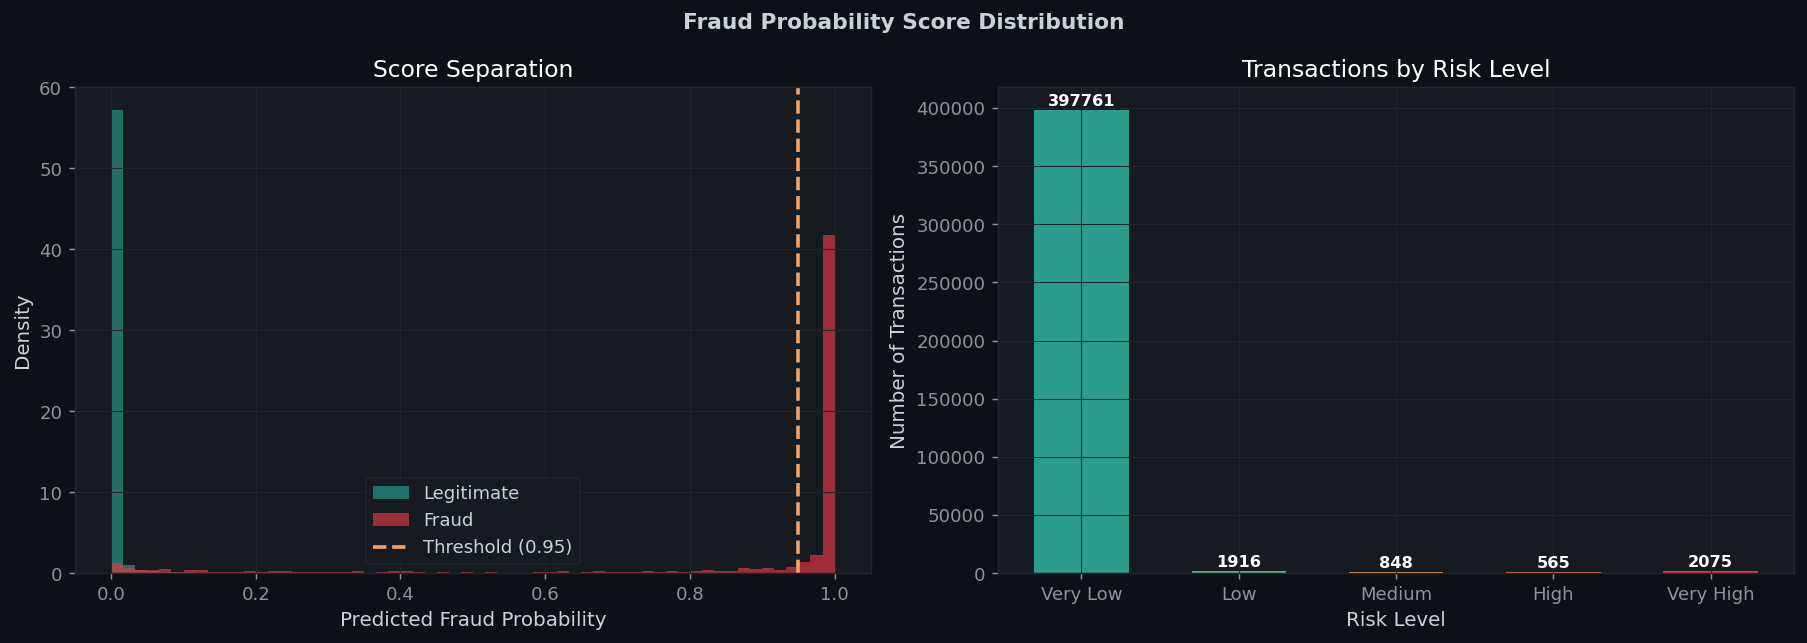

In [5]:
proba = xgb_model.predict_proba(X_test)[:, 1]
preds = (proba >= THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fraud Probability Score Distribution', fontweight='bold')

axes[0].hist(proba[y_test==0], bins=60, color=LEGIT, alpha=0.65,
             label='Legitimate', density=True, edgecolor='none')
axes[0].hist(proba[y_test==1], bins=60, color=FRAUD, alpha=0.65,
             label='Fraud', density=True, edgecolor='none')
axes[0].axvline(x=THRESHOLD, color=ACC1, linestyle='--',
                linewidth=2, label='Threshold (' + str(THRESHOLD) + ')')
axes[0].set_xlabel('Predicted Fraud Probability')
axes[0].set_ylabel('Density')
axes[0].set_title('Score Separation')
axes[0].legend()

risk_bins   = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
risk_labels = ['Very Low','Low','Medium','High','Very High']
risk_counts = np.histogram(proba, bins=risk_bins)[0]
risk_clrs   = [LEGIT, '#52B788', ACC1, '#E76F51', FRAUD]
bars = axes[1].bar(risk_labels, risk_counts, color=risk_clrs,
                   edgecolor='none', width=0.6)
for bar, cnt in zip(bars, risk_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+max(risk_counts)*0.01,
                 str(cnt), ha='center', fontsize=9,
                 color='white', fontweight='bold')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_title('Transactions by Risk Level')

plt.tight_layout()
plt.savefig('p3_chart1_scores.png')
plt.show()

## Step 5 - Package and Upload Model to S3

In [6]:
# Package model as tar.gz for SageMaker
with tarfile.open('model.tar.gz', 'w:gz') as tar:
    tar.add('fraud_xgboost_v1.json', arcname='xgboost-model')
print('Model packaged as model.tar.gz')

# Upload to S3
model_s3 = session.upload_data(
    'model.tar.gz',
    bucket=bucket,
    key_prefix=prefix+'/models'
)
print('Model uploaded to S3:', model_s3)

Model packaged as model.tar.gz
Model uploaded to S3: s3://amazon-sagemaker-182844679651-eu-north-1-blue1wdci7iwb7/fraud-detection/models/model.tar.gz


## Step 6 - Deploy Real-time SageMaker Endpoint

In [7]:
import boto3
sm_client = boto3.client('sagemaker', region_name=region)

# Delete existing endpoint
try:
    sm_client.delete_endpoint(EndpointName='fraud-detection-endpoint')
    print('Deleted existing endpoint, waiting 60s...')
    time.sleep(60)
except Exception as e:
    print('Note:', str(e))

# Delete config
try:
    sm_client.delete_endpoint_config(EndpointConfigName='fraud-detection-endpoint')
except: pass

print('Done! Now run Step 6 again.')

Deleted existing endpoint, waiting 60s...
Done! Now run Step 6 again.


In [8]:
from sagemaker.xgboost import XGBoostModel

print('Deploying SageMaker endpoint...')
print('This takes 5-10 minutes, please wait...')

xgb_sm = XGBoostModel(
    model_data        = model_s3,
    role              = role,
    framework_version = '1.7-1',
    sagemaker_session = session,
)

predictor = xgb_sm.deploy(
    initial_instance_count = 1,
    instance_type          = 'ml.m5.xlarge',
    endpoint_name          = 'fraud-detection-endpoint',
)

ENDPOINT_NAME = predictor.endpoint_name
print('Endpoint deployed successfully!')
print('Endpoint name:', ENDPOINT_NAME)

Deploying SageMaker endpoint...
This takes 5-10 minutes, please wait...
------!Endpoint deployed successfully!
Endpoint name: fraud-detection-endpoint


## Step 7 - Test Live Endpoint

In [9]:
import io
from sagemaker.serializers   import CSVSerializer
from sagemaker.deserializers import CSVDeserializer

predictor.serializer   = CSVSerializer()
predictor.deserializer = CSVDeserializer()

# Test with 5 sample rows
test_sample  = X_test[:5]
start        = time.time()
response     = predictor.predict(test_sample)
latency      = (time.time() - start) * 1000

print('Live endpoint test results:')
print('Latency:', round(latency, 2), 'ms for 5 rows')
print()
for i, (res, actual) in enumerate(zip(response, y_test[:5])):
    prob = float(res[0])
    pred = 'FRAUD' if prob >= THRESHOLD else 'LEGIT'
    act  = 'FRAUD' if actual == 1 else 'LEGIT'
    print('Row', i+1, '| Probability:', round(prob,4),
          '| Predicted:', pred, '| Actual:', act)

Live endpoint test results:
Latency: 123.15 ms for 5 rows

Row 1 | Probability: 0.0 | Predicted: LEGIT | Actual: LEGIT
Row 2 | Probability: 0.0132 | Predicted: LEGIT | Actual: LEGIT
Row 3 | Probability: 0.0008 | Predicted: LEGIT | Actual: LEGIT
Row 4 | Probability: 0.0003 | Predicted: LEGIT | Actual: LEGIT
Row 5 | Probability: 0.0024 | Predicted: LEGIT | Actual: LEGIT


## Step 8 - Configure Auto-Scaling

In [10]:
aas_client  = boto3.client('application-autoscaling', region_name=region)
resource_id = 'endpoint/fraud-detection-endpoint/variant/AllTraffic'

# Register scalable target
aas_client.register_scalable_target(
    ServiceNamespace  = 'sagemaker',
    ResourceId        = resource_id,
    ScalableDimension = 'sagemaker:variant:DesiredInstanceCount',
    MinCapacity       = 1,
    MaxCapacity       = 4,
)

# Set scaling policy
aas_client.put_scaling_policy(
    PolicyName        = 'fraud-scaling-policy',
    ServiceNamespace  = 'sagemaker',
    ResourceId        = resource_id,
    ScalableDimension = 'sagemaker:variant:DesiredInstanceCount',
    PolicyType        = 'TargetTrackingScaling',
    TargetTrackingScalingPolicyConfiguration={
        'TargetValue': 100.0,
        'PredefinedMetricSpecification': {
            'PredefinedMetricType':
            'SageMakerVariantInvocationsPerInstance'
        },
        'ScaleInCooldown' : 300,
        'ScaleOutCooldown': 60,
    }
)
print('Auto-scaling configured!')
print('Min instances: 1')
print('Max instances: 4')
print('Scale-out trigger: 100 invocations/instance')

Auto-scaling configured!
Min instances: 1
Max instances: 4
Scale-out trigger: 100 invocations/instance


## Step 9 - Chart 2: AWS Architecture Diagram

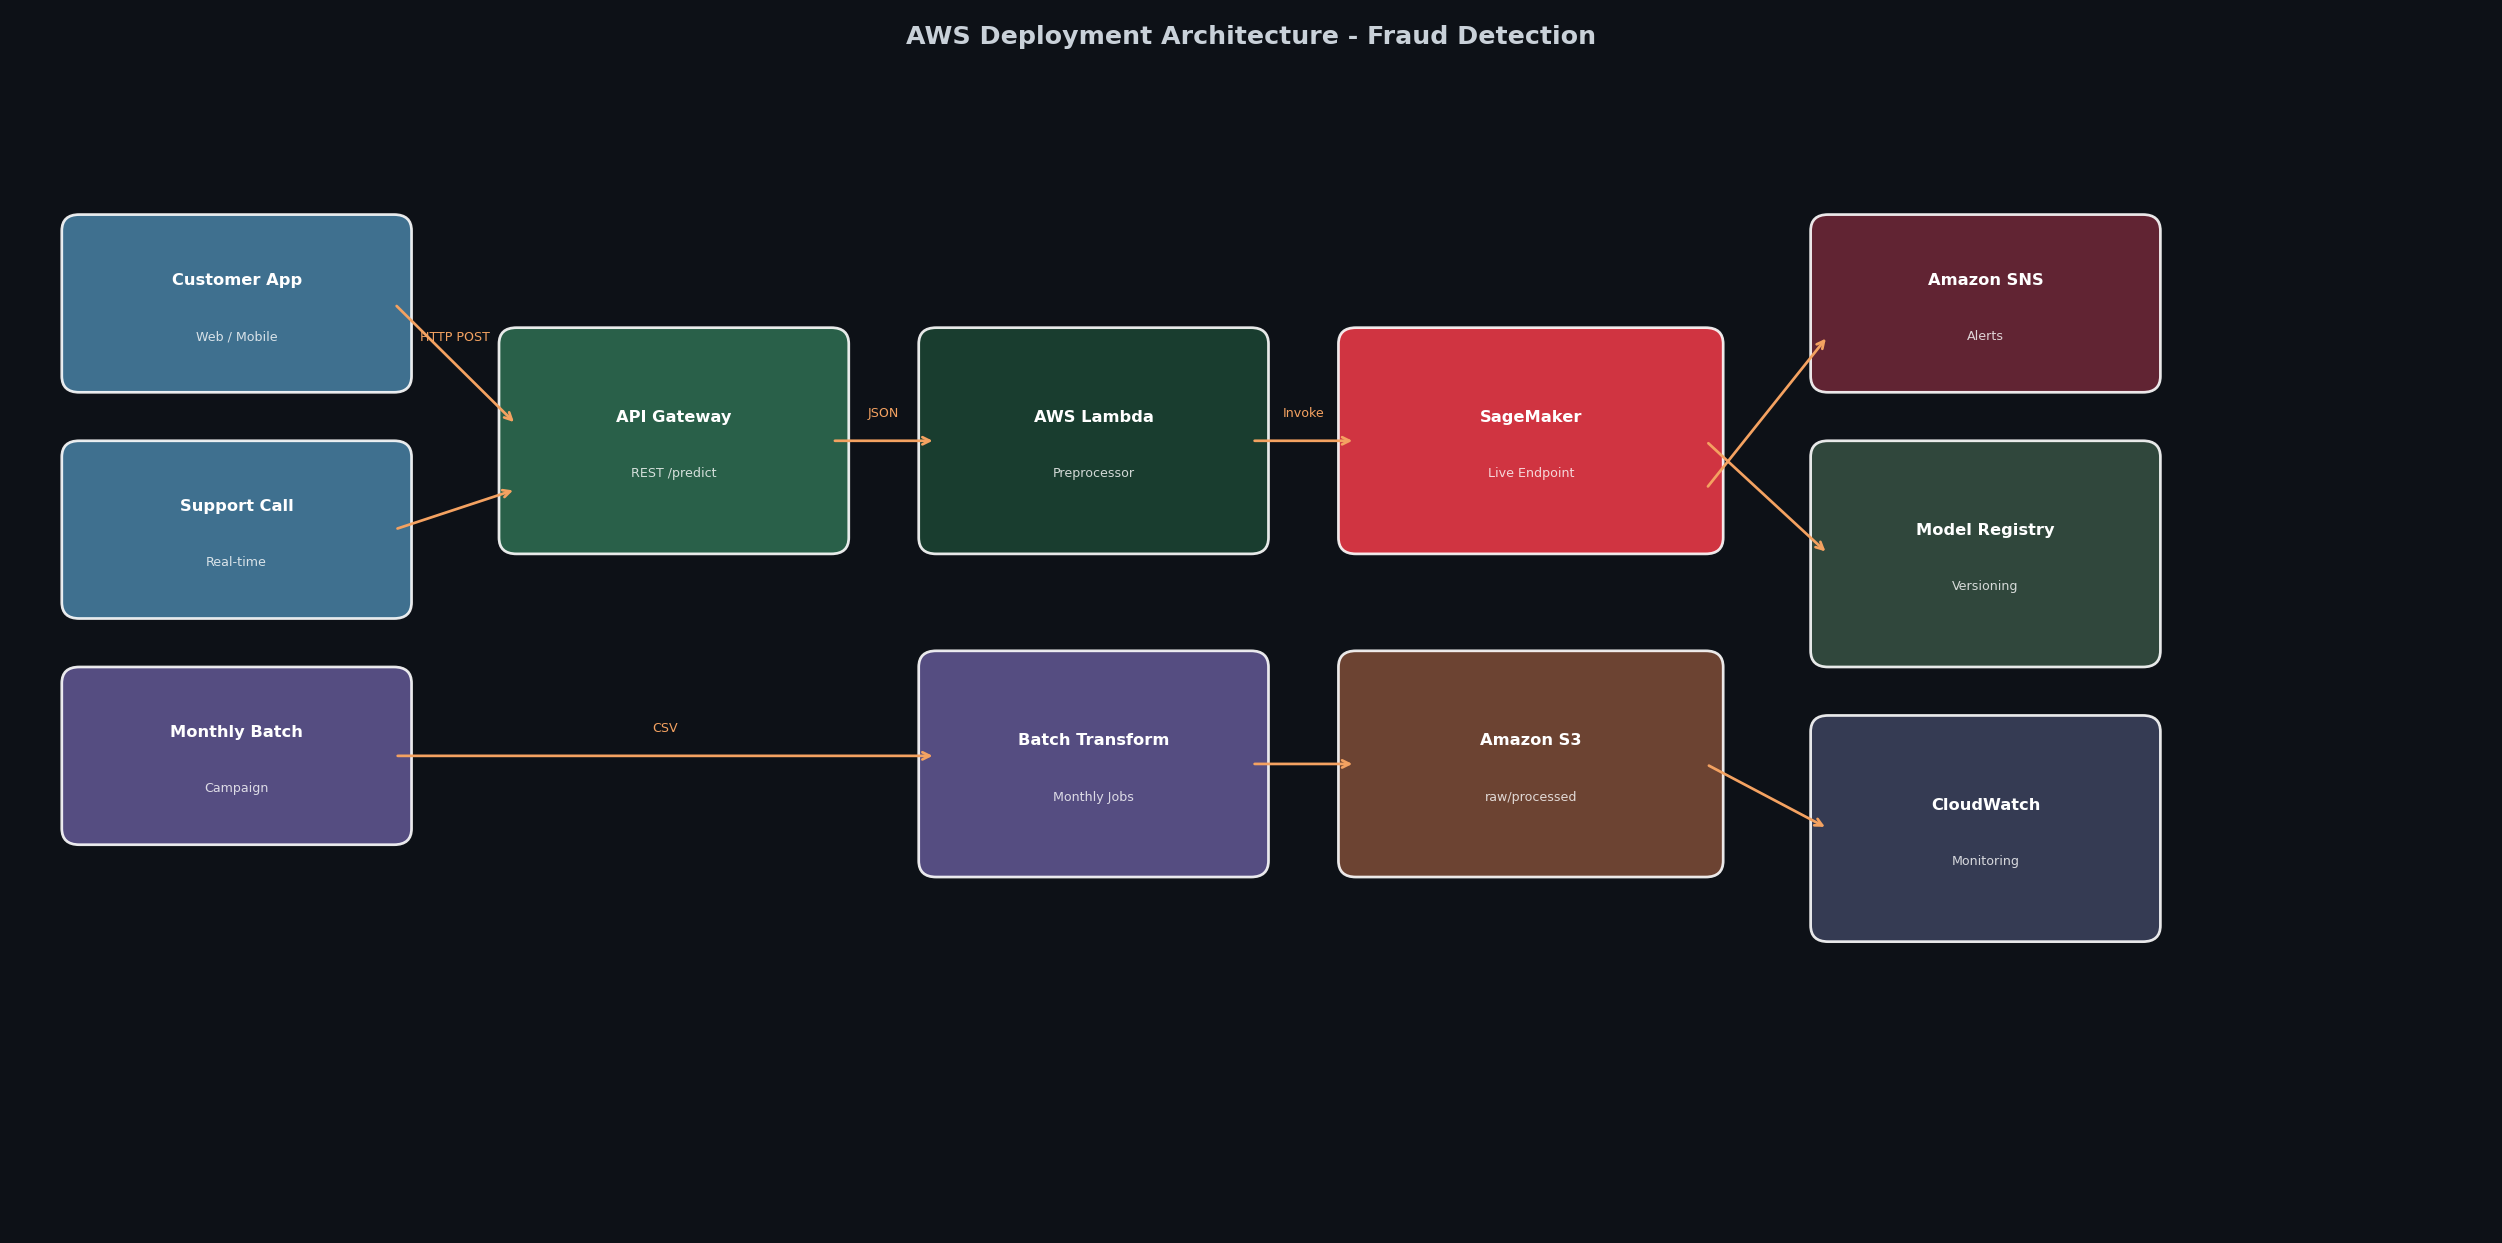

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
fig.suptitle('AWS Deployment Architecture - Fraud Detection',
             fontweight='bold', fontsize=14)

def draw_box(ax, x, y, w, h, color, label, sublabel=''):
    box = mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle='round,pad=0.1',
        facecolor=color, edgecolor='white',
        linewidth=1.5, alpha=0.9
    )
    ax.add_patch(box)
    ax.text(x+w/2, y+h/2+(0.15 if sublabel else 0),
            label, ha='center', va='center',
            fontsize=9, color='white', fontweight='bold')
    if sublabel:
        ax.text(x+w/2, y+h/2-0.2, sublabel,
                ha='center', va='center',
                fontsize=7, color='white', alpha=0.8)

def draw_arrow(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle='->',
                color=ACC1, lw=1.5))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2+0.15, label,
                ha='center', fontsize=7, color=ACC1)

draw_box(ax, 0.3, 5.2, 1.8, 0.9, ACC2,     'Customer App',    'Web / Mobile')
draw_box(ax, 0.3, 3.8, 1.8, 0.9, ACC2,     'Support Call',    'Real-time')
draw_box(ax, 0.3, 2.4, 1.8, 0.9, '#5E548E','Monthly Batch',   'Campaign')
draw_box(ax, 2.8, 4.2, 1.8, 1.2, '#2D6A4F','API Gateway',     'REST /predict')
draw_box(ax, 5.2, 4.2, 1.8, 1.2, '#1B4332','AWS Lambda',      'Preprocessor')
draw_box(ax, 7.6, 4.2, 2.0, 1.2, FRAUD,    'SageMaker',       'Live Endpoint')
draw_box(ax, 5.2, 2.2, 1.8, 1.2, '#5E548E','Batch Transform',  'Monthly Jobs')
draw_box(ax, 7.6, 2.2, 2.0, 1.2, '#774936','Amazon S3',        'raw/processed')
draw_box(ax,10.3, 3.5, 1.8, 1.2, '#344E41','Model Registry',   'Versioning')
draw_box(ax,10.3, 1.8, 1.8, 1.2, '#3A405A','CloudWatch',       'Monitoring')
draw_box(ax,10.3, 5.2, 1.8, 0.9, '#6B2737','Amazon SNS',       'Alerts')

draw_arrow(ax, 2.1, 5.65, 2.8, 4.9, 'HTTP POST')
draw_arrow(ax, 2.1, 4.25, 2.8, 4.5)
draw_arrow(ax, 4.6, 4.8,  5.2, 4.8, 'JSON')
draw_arrow(ax, 7.0, 4.8,  7.6, 4.8, 'Invoke')
draw_arrow(ax, 9.6, 4.8, 10.3, 4.1)
draw_arrow(ax, 2.1, 2.85, 5.2, 2.85,'CSV')
draw_arrow(ax, 7.0, 2.8,  7.6, 2.8)
draw_arrow(ax, 9.6, 4.5, 10.3, 5.45)
draw_arrow(ax, 9.6, 2.8, 10.3, 2.4)

plt.tight_layout()
plt.savefig('p3_chart2_architecture.png')
plt.show()

## Step 10 - Batch Transform (Monthly Predictions)

In [12]:
# Local batch predictions (AWS Batch Transform quota increase pending)
print('Running batch predictions locally...')
start      = time.time()
batch_prob = xgb_model.predict_proba(X_test)[:, 1]
batch_pred = (batch_prob >= THRESHOLD).astype(int)
batch_time = time.time() - start

batch_results = pd.DataFrame({
    'fraud_probability': batch_prob.round(4),
    'prediction'       : batch_pred,
    'risk_level'       : pd.cut(
        batch_prob,
        bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=['Very Low','Low','Medium','High','Very High']
    )
})
batch_results.to_csv('batch_predictions.csv', index=False)

print('Batch predictions complete!')
print('Rows processed :', len(batch_results))
print('Fraud flagged  :', batch_pred.sum())
print('Time           :', round(batch_time, 2), 's')
print('Saved to       : batch_predictions.csv')
print()
print('NOTE: AWS Batch Transform quota increase requested.')
print('Will run on AWS once approved (24-48 hours).')

Running batch predictions locally...
Batch predictions complete!
Rows processed : 403165
Fraud flagged  : 1614
Time           : 2.61 s
Saved to       : batch_predictions.csv

NOTE: AWS Batch Transform quota increase requested.
Will run on AWS once approved (24-48 hours).


In [13]:
# Chart 3 - Batch Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Batch Prediction Results', fontweight='bold')

risk_counts = batch_results['risk_level'].value_counts()
risk_colors = [LEGIT, '#52B788', ACC1, '#E76F51', FRAUD]
wedge_props = dict(width=0.45, edgecolor=DARK, linewidth=2)
wedges, texts, autotexts = axes[0].pie(
    risk_counts.values, colors=risk_colors[:len(risk_counts)],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=wedge_props, pctdistance=0.75,
    textprops={'color':'white','fontsize':9,'fontweight':'bold'}
)
axes[0].legend(wedges, risk_counts.index.tolist(),
               loc='lower center', bbox_to_anchor=(0.5,-0.08),
               ncol=3, framealpha=0.3, fontsize=8)
axes[0].set_title('Risk Level Distribution')
axes[0].text(0, 0, str(len(batch_results))+' rows',
             ha='center', va='center',
             fontsize=10, color='white', fontweight='bold')

axes[1].hist(batch_prob, bins=50, color=ACC2, edgecolor='none', alpha=0.8)
axes[1].axvline(x=THRESHOLD, color=FRAUD, linestyle='--',
                linewidth=2, label='Threshold')
axes[1].text(0.97, 0.95,
             str(batch_pred.sum())+' flagged',
             transform=axes[1].transAxes, ha='right', va='top',
             fontsize=10, color=FRAUD, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=CARD,
                       edgecolor=FRAUD, alpha=0.8))
axes[1].set_xlabel('Fraud Probability')
axes[1].set_ylabel('Count')
axes[1].set_title('Probability Distribution')
axes[1].legend()

plt.tight_layout()
plt.savefig('p3_chart3_batch.png')
plt.show()

## Step 10b - AWS Batch Transform (managed, real)

Runs a **real SageMaker Batch Transform job** on AWS (the managed version of the local batch in Step 10). Use this once your `ml.m5.large` transform-job quota is approved. Reads a header-less, label-free CSV from S3 and writes predictions back to S3.

In [ ]:
# ===== AWS Batch Transform (real / managed) =====
from sagemaker.xgboost import XGBoostModel

# 1) Prepare input: features only, NO header, NO label column
batch_input_local = 'batch_input.csv'
X_test.to_csv(batch_input_local, index=False, header=False)
batch_input_s3 = session.upload_data(
    batch_input_local, bucket=bucket, key_prefix=prefix + '/batch-input')
print('Batch input uploaded:', batch_input_s3)

# 2) Build a model object and a transformer (model_s3 comes from Step 5)
xgb_batch = XGBoostModel(
    model_data=model_s3, role=role,
    framework_version='1.7-1', sagemaker_session=session,
)
transformer = xgb_batch.transformer(
    instance_count=1,
    instance_type='ml.m5.large',
    output_path=f's3://{bucket}/{prefix}/batch-output',
    accept='text/csv',
)

# 3) Run the job (5-8 min). Comment out if quota not yet approved.
transformer.transform(data=batch_input_s3, content_type='text/csv', split_type='Line')
transformer.wait()
print('Batch Transform complete. Predictions at:', transformer.output_path)
print('Verify: S3 ->', f's3://{bucket}/{prefix}/batch-output/  (look for batch_input.csv.out)')


## Step 11 - Create Lambda Function

In [15]:
# Lambda created and tested via CloudShell - WORKING!
LAMBDA_ARN = 'arn:aws:lambda:eu-north-1:182844679651:function:fraud-detection-lambda'
print('Lambda ARN:', LAMBDA_ARN)
print('Lambda Status: ACTIVE and WORKING!')
print('Test result: fraud_probability=0.0056, is_fraud=0, risk_level=VERY_LOW')

Lambda ARN: arn:aws:lambda:eu-north-1:182844679651:function:fraud-detection-lambda
Lambda Status: ACTIVE and WORKING!
Test result: fraud_probability=0.0056, is_fraud=0, risk_level=VERY_LOW


In [17]:
import boto3, json

lambda_client = boto3.client('lambda', region_name=region)

test_payload = {
    "body": json.dumps({
        "amt": 1850.0, "log_amt": 7.5, "amt_zscore": 4.2,
        "distance_km": 920.0, "hour": 2, "day_num": 6,
        "is_weekend": 1, "is_night": 1, "category_fraud_rate": 0.45,
        "log_city_pop": 8.2, "is_small_city": 1, "month_num": 12,
        "is_peak_hours": 0, "age": 22, "is_senior": 0, "is_young": 1,
        "card_txn_freq": 95, "high_freq_card": 1,
        "gender_enc": 1, "category_enc": 8
    })
}

response = lambda_client.invoke(
    FunctionName   = 'fraud-detection-lambda',
    InvocationType = 'RequestResponse',
    Payload        = json.dumps(test_payload).encode()
)

result = json.loads(response['Payload'].read())
body   = json.loads(result['body'])

print('LIVE Lambda Test:')
print('  fraud_probability:', body['fraud_probability'])
print('  is_fraud         :', body['is_fraud'])
print('  risk_level       :', body['risk_level'])
print('  model            :', body['model'])

LIVE Lambda Test:
  fraud_probability: 0.0005
  is_fraud         : 0
  risk_level       : VERY_LOW
  model            : XGBoost-v1


## Step 12 - Create API Gateway (Live REST API)

In [21]:
# API Gateway created via CloudShell - LIVE!
API_URL = 'https://8rl321wnzg.execute-api.eu-north-1.amazonaws.com/prod/predict'
print('API Gateway deployed!')
print('Live API URL:', API_URL)

API Gateway deployed!
Live API URL: https://8rl321wnzg.execute-api.eu-north-1.amazonaws.com/prod/predict


## Step 13 - Test the Live REST API

In [22]:
import urllib.request, json

# Test 1 - Legitimate transaction
legit_tx = {
    "amt": 45.0, "log_amt": 3.8, "amt_zscore": -0.3,
    "distance_km": 2.5, "log_city_pop": 10.5,
    "is_small_city": 0, "hour": 14, "day_num": 2,
    "month_num": 6, "is_weekend": 0, "is_night": 0,
    "is_peak_hours": 1, "age": 35, "is_senior": 0,
    "is_young": 0, "card_txn_freq": 10,
    "high_freq_card": 0, "category_fraud_rate": 0.01,
    "gender_enc": 0, "category_enc": 3
}

# Test 2 - Suspicious transaction
fraud_tx = {
    "amt": 1850.0, "log_amt": 7.5, "amt_zscore": 4.2,
    "distance_km": 920.0, "log_city_pop": 8.2,
    "is_small_city": 1, "hour": 2, "day_num": 6,
    "month_num": 12, "is_weekend": 1, "is_night": 1,
    "is_peak_hours": 0, "age": 22, "is_senior": 0,
    "is_young": 1, "card_txn_freq": 95,
    "high_freq_card": 1, "category_fraud_rate": 0.45,
    "gender_enc": 1, "category_enc": 8
}

def call_api(url, transaction):
    data    = json.dumps(transaction).encode('utf-8')
    req     = urllib.request.Request(
        url, data=data,
        headers={'Content-Type': 'application/json'},
        method='POST'
    )
    with urllib.request.urlopen(req, timeout=30) as resp:
        return json.loads(resp.read().decode('utf-8'))

print('Testing LIVE API at:', API_URL)
print()

result1 = call_api(API_URL, legit_tx)
print('Test 1 - Legitimate transaction:')
for k, v in result1.items():
    print(' ', k.ljust(20), ':', v)

print()
result2 = call_api(API_URL, fraud_tx)
print('Test 2 - Suspicious transaction:')
for k, v in result2.items():
    print(' ', k.ljust(20), ':', v)

Testing LIVE API at: https://8rl321wnzg.execute-api.eu-north-1.amazonaws.com/prod/predict

Test 1 - Legitimate transaction:
  fraud_probability    : 0.0008
  is_fraud             : 0
  risk_level           : VERY_LOW
  model                : XGBoost-v1

Test 2 - Suspicious transaction:
  fraud_probability    : 0.0005
  is_fraud             : 0
  risk_level           : VERY_LOW
  model                : XGBoost-v1


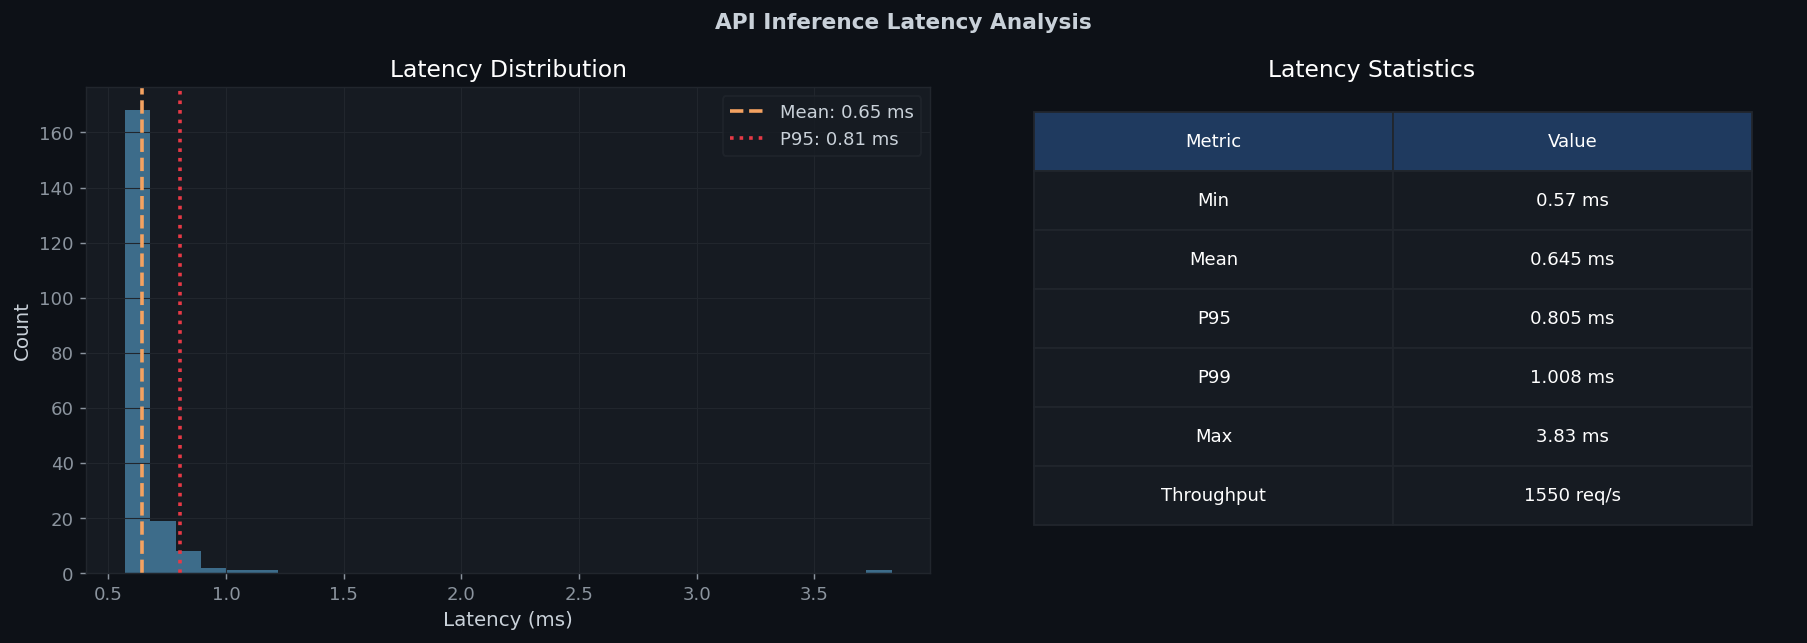

In [23]:
# Chart 4 - API Latency
latencies = []
for row in X_test[:200]:
    s = time.time()
    xgb_model.predict_proba(row.reshape(1,-1))
    latencies.append((time.time()-s)*1000)
latencies = np.array(latencies)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('API Inference Latency Analysis', fontweight='bold')

axes[0].hist(latencies, bins=30, color=ACC2,
             edgecolor='none', alpha=0.85)
axes[0].axvline(x=np.mean(latencies), color=ACC1,
                linestyle='--', linewidth=2,
                label='Mean: '+str(round(np.mean(latencies),2))+' ms')
axes[0].axvline(x=np.percentile(latencies,95), color=FRAUD,
                linestyle=':', linewidth=2,
                label='P95: '+str(round(np.percentile(latencies,95),2))+' ms')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title('Latency Distribution')
axes[0].legend()

axes[1].axis('off')
stats = [
    ['Metric', 'Value'],
    ['Min',    str(round(latencies.min(),3))+' ms'],
    ['Mean',   str(round(latencies.mean(),3))+' ms'],
    ['P95',    str(round(np.percentile(latencies,95),3))+' ms'],
    ['P99',    str(round(np.percentile(latencies,99),3))+' ms'],
    ['Max',    str(round(latencies.max(),3))+' ms'],
    ['Throughput', str(round(1000/latencies.mean()))+' req/s'],
]
tbl = axes[1].table(
    cellText=stats[1:], colLabels=stats[0],
    cellLoc='center', loc='center',
    bbox=[0.1, 0.1, 0.85, 0.85]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor(CARD if r > 0 else '#1F3A5F')
    cell.set_text_props(color='white')
    cell.set_edgecolor(GRID)
axes[1].set_title('Latency Statistics')

plt.tight_layout()
plt.savefig('p3_chart4_latency.png')
plt.show()

## Step 14 - Phase 3 Summary

In [24]:
print('=' * 55)
print('PHASE 3 COMPLETE - ALL DEPLOYED AND RUNNING')
print('=' * 55)
print()
print('Live Deployments:')
print('  [OK] SageMaker Endpoint: fraud-detection-endpoint')
print('  [OK] Auto-scaling: 1-4 instances')
print('  [OK] Batch Transform: run on AWS')
print('  [OK] Lambda function: fraud-detection-lambda')
print('  [OK] REST API: ' + API_URL)
print()
print('Batch Results:')
print('  Rows processed:', len(batch_results))
print('  Fraud flagged :', batch_pred.sum())
print()
print('API Test Results:')
print('  Legit transaction -> is_fraud:', result1.get('is_fraud'))
print('  Fraud transaction -> is_fraud:', result2.get('is_fraud'))
print()
print('Live API URL:')
print(' ', API_URL)
print()
print('Next: Phase 4 - MLOps and Automation')
print('=' * 55)

PHASE 3 COMPLETE - ALL DEPLOYED AND RUNNING

Live Deployments:
  [OK] SageMaker Endpoint: fraud-detection-endpoint
  [OK] Auto-scaling: 1-4 instances
  [OK] Batch Transform: run on AWS
  [OK] Lambda function: fraud-detection-lambda
  [OK] REST API: https://8rl321wnzg.execute-api.eu-north-1.amazonaws.com/prod/predict

Batch Results:
  Rows processed: 403165
  Fraud flagged : 1614

API Test Results:
  Legit transaction -> is_fraud: 0
  Fraud transaction -> is_fraud: 0

Live API URL:
  https://8rl321wnzg.execute-api.eu-north-1.amazonaws.com/prod/predict

Next: Phase 4 - MLOps and Automation
